# Zero-shot BRCA1 variant effect prediction with Nucleotide Transformer v3

This notebook is inspired by the Arc Institute Evo2 example
[`brca1_zero_shot_vep.ipynb`](https://github.com/ArcInstitute/evo2/blob/main/notebooks/brca1/brca1_zero_shot_vep.ipynb),
but uses **[`InstaDeepAI/NTv3_650M_pre`](https://huggingface.co/InstaDeepAI/NTv3_650M_pre)**
via 🤗 `transformers` instead of Evo2.

We will reproduce the same experiment: zero-shot classification of *BRCA1* single-nucleotide
variants (SNVs) from the saturation genome editing (SGE) study of
[Findlay et al. 2018](https://www.nature.com/articles/s41586-018-0461-z), using
the likelihood's produced by the pretrained genomic language model, without any task-specific fine-tuning. This is what we call *zero-shot* prediction.

NTv3 (in its `_pre` / MLM checkpoint) is a **masked language model**, so it uses the
**masked-marginal / pseudo-log-likelihood scoring** scheme.

1. Take the reference genomic window centered on the variant.
2. Replace only the single nucleotide at the variant position with the model's `<mask>` token.
3. Run one forward pass and read off the model's predicted probability for the **reference**
   allele and the **alternate** allele at that masked position.
4. Score the variant as:

```
score = log P(alt | masked context) − log P(ref | masked context)
```

*Note: this method was popularised for protein variant
effect prediction by ESM-1v (Meier et al., 2021), and is used by many Nucleotide-Transformer-style genomic LLMs.*

A single masked forward pass gives us both probabilities we need. **Negative scores indicate that the alternate allele is disfavored relative to reference**, i.e. predicted to be more disruptive.

After making the zero-shot predictions, we will evaluate how well this zero-shot score separates loss-of-function (`LOF`) variants from functional/intermediate (`FUNC/INT`) variants.

## 1. Setup

Install the packages we need. `transformers>=4.55` is required for NTv3, and the model is
loaded with `trust_remote_code=True` because it ships custom modeling code on the Hub.

In [20]:
%%capture
!pip install -q "transformers>=4.55.0" torch accelerate biopython openpyxl scikit-learn matplotlib seaborn tqdm

In [21]:
import os
import gzip
import urllib.request

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModelForMaskedLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2. Download the BRCA1 SGE dataset and reference genome

We require two data files, both of which can be pulled from the Evo2 repository:
* The Findlay et al. 2018
supplementary table of BRCA1 SNV function scores
* A hg19/GRCh37 chromosome 17 FASTA (BRCA1
sits on chr17).

In [22]:
DATA_DIR = "brca1_data"
os.makedirs(DATA_DIR, exist_ok=True)

FILES = {
    "41586_2018_461_MOESM3_ESM.xlsx": (
        "https://raw.githubusercontent.com/ArcInstitute/evo2/main/"
        "notebooks/brca1/41586_2018_461_MOESM3_ESM.xlsx"
    ),
    "GRCh37.p13_chr17.fna.gz": (
        "https://raw.githubusercontent.com/ArcInstitute/evo2/main/"
        "notebooks/brca1/GRCh37.p13_chr17.fna.gz"
    ),
}

for fname, url in FILES.items():
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, fpath)
    else:
        print(f"{fname} already present.")

41586_2018_461_MOESM3_ESM.xlsx already present.
GRCh37.p13_chr17.fna.gz already present.


## 3. Load and prepare the BRCA1 SNV table

The supplementary table reports, for each SNV, an experimentally measured function score
(lower = more disruptive) and a three-way classification: `LOF` (loss-of-function), `INT`
(intermediate), and `FUNC` (functional). As in the original notebook, we collapse `FUNC` and
`INT` into a single `FUNC/INT` class and treat this as a binary classification problem
(`LOF` vs. `FUNC/INT`).

In [23]:
brca1_df = pd.read_excel(
    os.path.join(DATA_DIR, "41586_2018_461_MOESM3_ESM.xlsx"),
    header=2,
    nrows=100 # Read in only 100 rows to speed up our task
)
brca1_df = brca1_df[[
    "chromosome", "position (hg19)", "reference", "alt", "function.score.mean", "func.class",
]]
brca1_df.rename(columns={
    "chromosome": "chrom",
    "position (hg19)": "pos",
    "reference": "ref",
    "alt": "alt",
    "function.score.mean": "score",
    "func.class": "class",
}, inplace=True)

# Collapse FUNC and INT into a single FUNC/INT class, keep LOF separate.
brca1_df["class"] = brca1_df["class"].replace(["FUNC", "INT"], "FUNC/INT")

print(brca1_df["class"].value_counts())
brca1_df.head(10)

class
FUNC/INT    88
LOF         12
Name: count, dtype: int64


,chrom,pos,ref,alt,score,class
0,17,41276135,T,G,-0.372611,FUNC/INT
1,17,41276135,T,C,-0.045313,FUNC/INT
2,17,41276135,T,A,-0.108254,FUNC/INT
3,17,41276134,T,G,-0.277963,FUNC/INT
4,17,41276134,T,C,-0.388414,FUNC/INT
5,17,41276134,T,A,-0.280973,FUNC/INT
6,17,41276133,C,T,-0.973683,FUNC/INT
7,17,41276133,C,G,-0.373489,FUNC/INT
8,17,41276133,C,A,0.006314,FUNC/INT
9,17,41276132,A,T,-0.207552,FUNC/INT


## 4. Load the chr17 reference sequence and build variant windows

For every SNV we extract a fixed-size window of reference genome sequence centered on the
variant. NTv3 supports very long context (its long-context checkpoints go up to ~1 Mb), but we
use an 8,192 bp window here to keep runtime reasonable and to mirror the window size used in
the Evo 2 notebook — feel free to increase `WINDOW_SIZE` if you have more compute available.
NTv3 requires the input length to be a multiple of 128, so `WINDOW_SIZE` is chosen accordingly
(8192 = 64 × 128).

In [26]:
with gzip.open(os.path.join(DATA_DIR, "GRCh37.p13_chr17.fna.gz"), "rt") as handle:
    for record in SeqIO.parse(handle, "fasta"):
        seq_chr17 = str(record.seq).upper()
        break

print(f"Loaded chr17, length = {len(seq_chr17):,} bp")

WINDOW_SIZE = 8192
assert WINDOW_SIZE % 128 == 0, "NTv3 requires sequence lengths that are a multiple of 128"


def get_variant_window(pos: int, ref: str, alt: str, window_size: int = WINDOW_SIZE):
    '''
    Extract a reference-genome window centered on a 1-based hg19 SNV position.
    Returns the window sequence and the 0-based index of the variant within that window.
    Raises a ValueError if the reference base at `pos` does not match the FASTA (sanity check).
    '''
    p0 = pos - 1  # convert to 0-based
    if seq_chr17[p0] != ref:
        raise ValueError(
            f"Reference base mismatch at pos {pos}: FASTA has {seq_chr17[p0]!r}, expected {ref!r}"
        )

    half = window_size // 2
    start = p0 - half
    end = start + window_size
    window_seq = seq_chr17[start:end]
    variant_idx = p0 - start  # index of the variant base within window_seq

    assert len(window_seq) == window_size
    assert window_seq[variant_idx] == ref
    return window_seq, variant_idx


# Sanity check on the first variant.
row = brca1_df.iloc[0]
win, idx = get_variant_window(int(row["pos"]), row["ref"], row["alt"])
print(f"Window length: {len(win)}, variant at index {idx}: {win[idx]} -> {row['alt']}")

Loaded chr17, length = 81,195,210 bp
Window length: 8192, variant at index 4096: T -> G


## 5. Load NTv3

We load `InstaDeepAI/NTv3_650M_pre` as a masked language model. The tokenizer is
character-level over `A T C G N` plus special tokens, so a single nucleotide corresponds to a
single token — exactly what the masked-marginal scoring scheme needs.

In [27]:
MODEL_NAME = "InstaDeepAI/NTv3_650M_pre"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForMaskedLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)
model.to(device)
model.eval()

mask_token_id = tokenizer.mask_token_id
nucleotide_ids = {b: tokenizer.convert_tokens_to_ids(b) for b in "ACGT"}
print("Mask token id:", mask_token_id)
print("Nucleotide token ids:", nucleotide_ids)

Loading weights:   0%|          | 0/297 [00:00<?, ?it/s]

Mask token id: 2
Nucleotide token ids: {'A': 6, 'C': 8, 'G': 9, 'T': 7}


## 6. Masked-marginal scoring

For each variant we:

1. Tokenize the reference window (one token per base, no added special tokens so indices line
   up 1:1 with `window_seq`).
2. Overwrite the token at the variant position with `<mask>`.
3. Run a forward pass and take the log-softmax of the logits at that position.
4. Read off `log P(ref)` and `log P(alt)` and compute `score = log P(alt) - log P(ref)`.

We batch variants together for speed. Because every window has the same length (`WINDOW_SIZE`),
we can stack them into a single tensor without padding.

In [28]:
@torch.no_grad()
def score_batch(windows, variant_indices, refs, alts):
    '''
    Compute masked-marginal LLR scores for a batch of variants.
    windows: list[str] reference windows (all the same length)
    variant_indices: list[int] 0-based index of the variant within each window
    refs, alts: list[str] single-character reference / alternate alleles
    '''
    encoded = tokenizer(
        windows,
        add_special_tokens=False,
        return_tensors="pt",
    )
    input_ids = encoded["input_ids"].clone()
    # All windows are the same fixed length (no padding), so the tokenizer may omit
    # `attention_mask` entirely. Build an all-ones mask ourselves to be safe either way.
    attention_mask = encoded.get("attention_mask")
    if attention_mask is None:
        attention_mask = torch.ones_like(input_ids)

    batch_idx = torch.arange(len(windows))
    var_pos = torch.tensor(variant_indices)

    # Sanity check: token at the variant position should currently equal the ref allele.
    ref_ids = torch.tensor([nucleotide_ids[r] for r in refs])
    assert torch.equal(input_ids[batch_idx, var_pos], ref_ids), "ref allele / token mismatch"

    # Mask out the variant position.
    input_ids[batch_idx, var_pos] = mask_token_id

    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)

    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits if hasattr(out, "logits") else out["logits"]
    log_probs = F.log_softmax(logits.float(), dim=-1)

    masked_log_probs = log_probs[batch_idx, var_pos]  # (batch, vocab)

    alt_ids = torch.tensor([nucleotide_ids[a] for a in alts])
    ref_lp = masked_log_probs[batch_idx, ref_ids.to(device)]
    alt_lp = masked_log_probs[batch_idx, alt_ids.to(device)]

    return (alt_lp - ref_lp).cpu().numpy()

In [29]:
BATCH_SIZE = 8  # lower this if you run out of GPU memory

windows, variant_indices, refs, alts, valid_rows = [], [], [], [], []

for i, row in brca1_df.iterrows():
    try:
        win, idx = get_variant_window(int(row["pos"]), row["ref"], row["alt"])
    except ValueError:
        continue  # skip variants whose ref base doesn't match the FASTA (indels, strand issues)
    windows.append(win)
    variant_indices.append(idx)
    refs.append(row["ref"])
    alts.append(row["alt"])
    valid_rows.append(i)

print(f"Scoring {len(windows)} / {len(brca1_df)} variants")

scores = np.empty(len(windows), dtype=np.float32)
for start in tqdm(range(0, len(windows), BATCH_SIZE)):
    end = start + BATCH_SIZE
    scores[start:end] = score_batch(
        windows[start:end],
        variant_indices[start:end],
        refs[start:end],
        alts[start:end],
    )

scored_df = brca1_df.loc[valid_rows].copy()
scored_df["ntv3_score"] = scores
scored_df.head(10)

Scoring 100 / 100 variants


  0%|          | 0/13 [00:00<?, ?it/s]

,chrom,pos,ref,alt,score,class,ntv3_score
0,17,41276135,T,G,-0.372611,FUNC/INT,1.847569
1,17,41276135,T,C,-0.045313,FUNC/INT,-0.251995
2,17,41276135,T,A,-0.108254,FUNC/INT,0.886116
3,17,41276134,T,G,-0.277963,FUNC/INT,-1.552906
4,17,41276134,T,C,-0.388414,FUNC/INT,-0.447101
5,17,41276134,T,A,-0.280973,FUNC/INT,1.297855
6,17,41276133,C,T,-0.973683,FUNC/INT,1.404816
7,17,41276133,C,G,-0.373489,FUNC/INT,1.038864
8,17,41276133,C,A,0.006314,FUNC/INT,2.958321
9,17,41276132,A,T,-0.207552,FUNC/INT,0.152412


## 7. Evaluate against experimental function scores

Following the original notebook, we check whether the zero-shot NTv3 score separates
`LOF` variants from `FUNC/INT` variants. Since more negative scores indicate a more
disruptive alternate allele, we use `-ntv3_score` as the predictor of `LOF` status when
computing the ROC AUC.

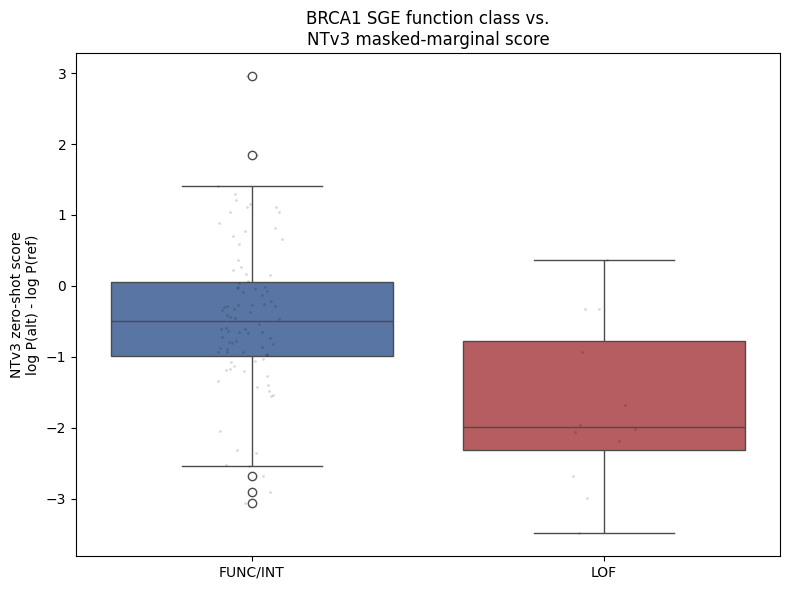

In [30]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=scored_df,
    x="class",
    y="ntv3_score",
    order=["FUNC/INT", "LOF"],
    hue="class",
    palette={"FUNC/INT": "#4C72B0", "LOF": "#C44E52"},
)
sns.stripplot(
    data=scored_df,
    x="class",
    y="ntv3_score",
    order=["FUNC/INT", "LOF"],
    color="black",
    alpha=0.15,
    size=2,
)
plt.ylabel("NTv3 zero-shot score\nlog P(alt) - log P(ref)")
plt.xlabel("")
plt.title("BRCA1 SGE function class vs.\nNTv3 masked-marginal score")
plt.tight_layout()
plt.show()

AUROC (LOF vs. FUNC/INT): 0.773


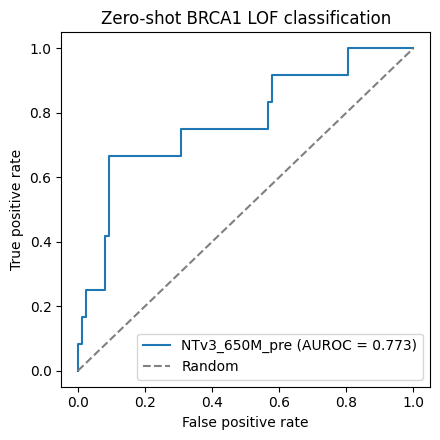

In [16]:
y_true = (scored_df["class"] == "LOF").astype(int).values
y_score = -scored_df["ntv3_score"].values  # more negative NTv3 score -> more likely LOF

auroc = roc_auc_score(y_true, y_score)
print(f"AUROC (LOF vs. FUNC/INT): {auroc:.3f}")

fpr, tpr, _ = roc_curve(y_true, y_score)
plt.figure(figsize=(4.5, 4.5))
plt.plot(fpr, tpr, label=f"NTv3_650M_pre (AUROC = {auroc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Zero-shot BRCA1 LOF classification")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Correlation with the continuous function score

Beyond the binary AUROC, we can also check how well the zero-shot score correlates with the
continuous, experimentally measured `function.score.mean` from the SGE assay.

Spearman correlation (NTv3 score vs. experimental function score): rho = 0.080, p = 4.31e-01


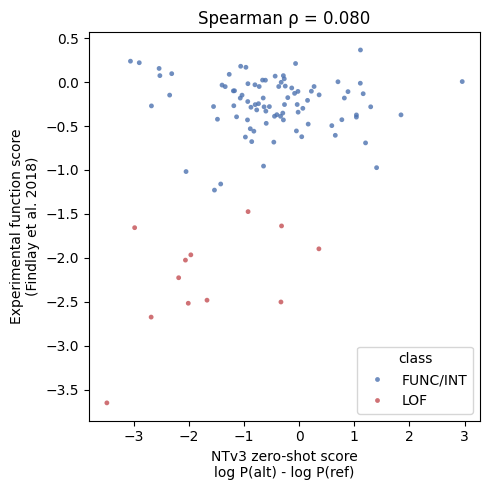

In [19]:
from scipy.stats import spearmanr

rho, p = spearmanr(scored_df["ntv3_score"], scored_df["score"])
print(f"Spearman correlation (NTv3 score vs. experimental function score): rho = {rho:.3f}, p = {p:.2e}")

plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=scored_df,
    x="ntv3_score",
    y="score",
    hue="class",
    hue_order=["FUNC/INT", "LOF"],
    palette={"FUNC/INT": "#4C72B0", "LOF": "#C44E52"},
    alpha=0.8,
    s=12,
    linewidth=0,
)
plt.xlabel("NTv3 zero-shot score\nlog P(alt) - log P(ref)")
plt.ylabel("Experimental function score\n(Findlay et al. 2018)")
plt.title(f"Spearman ρ = {rho:.3f}")
plt.tight_layout()
plt.show()

## Notes & next steps

- **Scoring scheme.** This notebook uses masked-marginal pseudo-log-likelihood scoring because
  NTv3's `_pre` checkpoint is a masked language model. If you instead want autoregressive-style
  scoring comparable to Evo2, you would need a causal NTv3 variant; the masked-marginal
  approach is the standard zero-shot scoring method for BERT-style genomic/protein language
  models (see Meier et al. 2021, "Language models enable zero-shot prediction of the effects of
  mutations on protein function", for the analogous protein version).
- **Context length.** We used an 8,192 bp window for speed and comparability with the Evo2
  notebook. NTv3's long-context checkpoints support much larger windows (up to ~1 Mb); widening
  the window may improve performance since it lets the model use more regulatory/splicing
  context around the variant.
- **Model size.** `InstaDeepAI/NTv3_650M_pre` is the 650M-parameter pretrained (MLM) checkpoint.
  InstaDeepAI also provides smaller (`8M`, `100M`) and post-trained (`_post`, with functional
  track heads) checkpoints that could be swapped in with minimal changes to this notebook.

## Sources/Acknowledgements
* **Data Source**: BRCA1 SGE function scores are from [Findlay, Braduno, Hause et al., *Nature* 2018](https://www.nature.com/articles/s41586-018-0461-z)
* **Code Source (Evo2)**: https://github.com/ArcInstitute/evo2/tree/main
* **Code Source (NTv3)**: https://huggingface.co/spaces/InstaDeepAI/ntv3/tree/main/notebooks_tutorials



## Want to try the original project with Evo2?
The notebook can be found here: [`brca1_zero_shot_vep.ipynb`](https://github.com/ArcInstitute/evo2/blob/main/notebooks/brca1/brca1_zero_shot_vep.ipynb), and all relevant files here: [`brca1`](https://github.com/ArcInstitute/evo2/tree/main/notebooks/brca1).

N.B.: As Evo2 is an **autoregressive** (causal) DNA language model, the variant scoring method is different to the above. Evo2 scores
a variant by comparing the model's *sequence log-likelihood* of the full reference window vs.
the full alternate window:

```
score = log P(alt sequence) − log P(ref sequence)
```